# E-tivity 3

* Pierce Currid

* 23260092

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits import mplot3d
import datetime as dt
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import plot_model # for plotting model diagram

from sklearn.decomposition import PCA, FactorAnalysis

from tensorflow import keras
from keras import Input
from keras import regularizers
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Dropout
from keras.optimizers import SGD, Adagrad, Adam

## Outline

Task - there are 3 tasks in this e-tivity. The first two tasks are group tasks. By this I mean that you will post the initial code implementing these tasks to your group via Group Locker. The group members can then comment on your approach, spot any omissions or mistakes, which you can then correct. The final task is to be completed without interaction with the group (that is your own work).

### Task 1

Implement tabular Q-Learning for the problem outlined in Example 6.5 (Windy Grid World) OR Example 6.6 (Cliff Walking Grid World) in the Reinforcement Learning Sutton and Barto’s text on Reinforcement Learning, 2nd Edition (2018)

(http://incompleteideas.net/book/the-book-2nd.html).

Consider the gridworld shown below.

*This is a standard undiscounted, episodic task, with start
and goal states, and the usual actions causing movement up, down,
right, and left. Reward is -1 on all
transitions except those into the region marked “The Cliff.” Stepping
into this region incurs a reward of
-100 and sends the agent instantly
back to the start.*

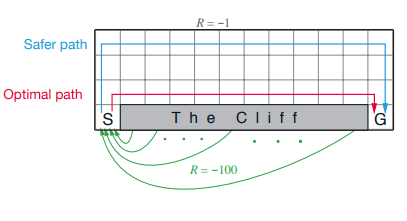

There's a subtle but important distinction between the 2 approaches to this problem space. The first approach is an off policy approach, called Q learning. Just a quick note on policies. These are basically strategies that the algorithm uses to pursue its goals. We can consider a policy basically a sequence of steps in a way.

Back to Q learning, this uses 2 policies:
1. one policy called the behaviour policy where the algorithm explores the environment.
2. another policy where it learns the state-action pairs and optimises called the target policy.

It updates its Q values based on the next actions best possible result. This approach means it often completes its goal, or converges faster. Although this can sometimes means it gets stuck in locals maximum values. It's called off policy because the actions that are executed are different from the target actions that are used for learning.

With the on policy approach - sarsa for instance,  the algorithm uses the same policy that simultaneously explores and learns the environment. Sarsa is more conservative in value estimation, meaning it can sometimes take a little longer to converge.


Both approaches are different as we will see in the results.



What we're looking to do here is maximise the sum of future rewards.

The grid is 4 x 12 cells, of which the cliff region takes up 10 cells. So we can say that there are 48 states. In terms of actions, we're limited to 2 dimensions, so the agent can take the actions left, right, up, down



---

Looked at a number of implementation examples online and borrowed from this primarily as a starting point:

https://medium.com/towards-data-science/reinforcement-learning-cliff-walking-implementation-e40ce98418d4


https://github.com/MJeremy2017/reinforcement-learning-implementation/blob/master/CliffWalking/cliffWalking.ipynb

Modified some elements of the code to make it more re-usable, and will continue to do so, especially in terms of plotting results


In [2]:
#create the Q space based on the state and action counts
no_rows = 4
no_cols = 12
cliff_area = np.zeros((no_rows,no_cols))

#create the actions
cliff_actions = ['up', 'down', 'left', 'right']

#start/finish positions: start = bottom left / finish = bottom right
start = (3,0)
finish = (3,11)

In [3]:
#helper functions
def show(cliff):
        for i in range(0, no_rows):
            print('-------------------------------------------------')
            out = '| '
            for j in range(0, no_cols):
                if cliff[i, j] == -1:
                    token = '*'
                if cliff[i, j] == 0:
                    token = '0'
                if (i, j) == start:
                    token = 'S'
                if (i, j) == finish:
                    token = 'G'
                out += token + ' | '
            print(out)
        print('-------------------------------------------------')

In [4]:
show(cliff_area)

-------------------------------------------------
| 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 
-------------------------------------------------
| 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 
-------------------------------------------------
| 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 
-------------------------------------------------
| S | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | G | 
-------------------------------------------------


In [5]:
class Cliff:

    def __init__(self, cliff_space):
        self.end = False
        self.pos = start
        self.board = cliff_space
        # add cliff marked as -1
        self.board[3, 1:11] = -1

    def nextMove(self, action):
        if action == "up":
            nxtPos = (self.pos[0]-1, self.pos[1])
        elif action == "down":
            nxtPos = (self.pos[0]+1, self.pos[1])
        elif action == "left":
            nxtPos = (self.pos[0], self.pos[1]-1)
        else:
            nxtPos = (self.pos[0], self.pos[1]+1)
        # check legitimacy
        if nxtPos[0] >= 0 and nxtPos[0] <= 3:
            if nxtPos[1] >= 0 and nxtPos[1] <= 11:
                self.pos = nxtPos

        if self.pos == finish:
            self.end = True
        if self.board[self.pos] == -1:
            self.end = True

        return self.pos

    def reward(self):
        # give reward
        if self.pos == finish:
            return -1
        if self.board[self.pos] == 0:
            return -1
        return -100

In [6]:
#cliff instance
cliff_walk = Cliff(cliff_area)

In [7]:
#Agent class
class Agent:
  def __init__(self, exp_rate, lr, start_location, actions, cliff_space):
    self.cliff = Cliff(cliff_space)
    self.exp_rate = exp_rate
    self.lr = lr
    self.states = []
    self.position = start_location
    self.actions = actions
    self.start = start_location
    self.state_actions = self.setStates(actions, cliff_area.shape[0], cliff_area.shape[1])

  def reset(self):
    self.cliff = Cliff(cliff_area)
    self.position = start
    self.states = []

  #sets the initial action state values in a dictionary with key of location tuple (state), and value of a dictionary with key value pairing for action/reward
  def setStates(self, actions, row, col):
    dict = {}
    for i in range(row):
      for j in range(col):
        dict[(i,j)] = {}
        for a in actions:
          dict[(i,j)][a] = 0
    return dict


  def nextAction(self):
    mx_nxt_reward = -999
    action = ""

    #greedy policy stuff
    if np.random.uniform(0, 1) <= self.exp_rate:
        action = np.random.choice(self.actions)

    else:
        for a in self.actions:
            current_position = self.position
            nxt_reward = self.state_actions[current_position][a]
            if nxt_reward >= mx_nxt_reward:
                action = a
                mx_nxt_reward = nxt_reward
    return action


  def play(self, rounds=10, qlearn = True):
      for i in range(rounds):
          while 1:
              curr_state = self.position
              cur_reward = self.cliff.reward()
              action = self.nextAction()

              # next position
              self.cliff.position = self.cliff.nextMove(action)
              self.position = self.cliff.position
              #print(curr_state, action, cur_reward)
              self.states.append([curr_state, action, cur_reward])
              if self.cliff.end:
                  break
          # game end update estimates
          reward = self.cliff.reward()
          #print("Game complete", reward)

          # reward of all actions in end state is same
          for a in self.actions:
              self.state_actions[self.position][a] = reward


          for s in reversed(self.states):
              position, action, r = s[0], s[1], s[2]
              #print(f"position, action, r: {s[0]} & {s[1]} & {s[2]}")
              current_value = self.state_actions[position][action]
              #print(f"current value: {current_value}")
              reward = current_value + self.lr * (r + reward - current_value)
              #print(f"reward: {current_value} + {self.lr} * {r} + {reward} - {current_value}")
              self.state_actions[position][action] = round(reward, 3)

              #as per q learning reward is defined as the best possible next value, in order words the max value
              if qlearn:
                reward = np.max(list(self.state_actions[position].values()))  # max
                #print(f"reward: {reward}")

          self.reset()




In [8]:
#agent instance
agent = Agent(0.2, 0.1, start, cliff_actions, cliff_area)
agent.play(rounds=500, qlearn=True)

In [9]:
def showRoute(states):
    board = np.zeros([4, 12])
    # add cliff marked as -1
    board[3, 1:11] = -1
    for i in range(0, no_rows):
        print('-------------------------------------------------')
        out = '| '
        for j in range(0, no_cols):
            token = '0'
            if board[i, j] == -1:
                token = '*'
            if (i, j) in states:
                token = 'R'
            if (i, j) == finish:
                token = 'F'
            out += token + ' | '
        print(out)
    print('-------------------------------------------------')

In [10]:
# Q-learning
#new instance of agent
ag_op = Agent(0.3, 0.1, start, cliff_actions, cliff_area)
ag_op.state_actions = agent.state_actions

In [11]:
def updateStates(agent):
  states = []
  i = 1
  while 1:
      curr_state = agent.position
      action = agent.nextAction()
      states.append(curr_state)
      print("current position {} |action {}".format(curr_state, action))

      # next position
      agent.cliff.pos = agent.cliff.nextMove(action)
      agent.position = agent.cliff.pos

      if agent.cliff.end:
        break
  print("total moves {}".format(len(states)))
  showRoute(states)

In [12]:
#showRoute(states)
updateStates(ag_op)

current position (3, 0) |action up
current position (2, 0) |action right
current position (2, 1) |action right
current position (2, 2) |action up
current position (1, 2) |action right
current position (1, 3) |action right
current position (1, 4) |action right
current position (1, 5) |action down
current position (2, 5) |action up
current position (1, 5) |action down
current position (2, 5) |action down
total moves 11
-------------------------------------------------
| 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 
-------------------------------------------------
| 0 | 0 | R | R | R | R | 0 | 0 | 0 | 0 | 0 | 0 | 
-------------------------------------------------
| R | R | R | 0 | 0 | R | 0 | 0 | 0 | 0 | 0 | 0 | 
-------------------------------------------------
| R | * | * | * | * | * | * | * | * | * | * | F | 
-------------------------------------------------


In [13]:
#sarsa experiments
agent_sarsa = Agent(0.2, 0.1, start, cliff_actions, cliff_area)
agent_sarsa.play(rounds=500, qlearn=False)

In [14]:
# SARSA
#new instance of agent
ag_op_sarsa = Agent(0.3, 0.1, start, cliff_actions, cliff_area)
ag_op_sarsa.state_actions = agent_sarsa.state_actions

In [15]:
#show sarsa routes
updateStates(ag_op_sarsa)

current position (3, 0) |action up
current position (2, 0) |action up
current position (1, 0) |action right
current position (1, 1) |action right
current position (1, 2) |action right
current position (1, 3) |action right
current position (1, 4) |action right
current position (1, 5) |action down
current position (2, 5) |action up
current position (1, 5) |action right
current position (1, 6) |action right
current position (1, 7) |action down
current position (2, 7) |action right
current position (2, 8) |action up
current position (1, 8) |action up
current position (0, 8) |action right
current position (0, 9) |action right
current position (0, 10) |action right
current position (0, 11) |action left
current position (0, 10) |action right
current position (0, 11) |action down
current position (1, 11) |action down
current position (2, 11) |action right
current position (2, 11) |action down
total moves 24
-------------------------------------------------
| 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | R |

#### TODO - more plots and evaluation work, as well as experiments based on the hyperparameters / parameters

## Task 1 Reflection
As we can see above, the Q learning approach led to a slightly more efficient path to the other side of the cliff, completing it in 13 moves vs 21 moves for Sarsa. This is expected as Q learning tends to be faster as it prioritises the optimal actions in that it always wants the next action that has the maximum reward, whereas sarsa as it learns from the steps it takes itself.



---



### **Task 2**
Using the Gymasium environment - formerly OpenAI Gym; Implement a  DQN for a classic control problem such as the Mountain Car or Pendulum.


https://medium.com/@samina.amin/deep-q-learning-dqn-71c109586bae


In [16]:
import tensorflow as tf
import numpy as np
import gym

from collections import deque
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

import random
import matplotlib.pyplot as plt

In [17]:
class DQNAgent:

    def __init__(self, state_size, action_size):

        self.state_size = state_size
        self.action_size = action_size

        # memory buffer, via a 2-way queue
        self.memory = deque(maxlen=10000)

        # Set algorithm hyperparameters
        self.gamma = 0.99
        self.epsilon = 1
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.98
        self.learning_rate = 0.001
        self.update_rate = 10

        # Create both Main and Target Networks
        self.main_network = self.create_nn()
        self.target_network = self.create_nn()

        # Initialize Target Network with Main Network's weights
        self.update_target_network()

    #The Deep part of this problem. Will extract this
    def create_nn(self):

        model = Sequential()

        model.add(Dense(64, activation='relu', input_dim=self.state_size))
        model.add(Dense(64, activation='relu'))
        model.add(Dense(self.action_size, activation='linear'))

        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))

        return model

    def update_target_network(self):
        # Method to set the Main NN's weights on the Target NN
        self.target_network.set_weights(self.main_network.get_weights())

    #save 'experiences' to memory
    def save_memory(self, state, action, reward, next_state, complete):
        self.memory.append((state, action, reward, next_state, complete))

    #retrieves a sample set of the previous experiences
    def sample_memory_batch(self, batch_size):
        batch = random.sample(self.memory, batch_size)

        # Create an array with the {batchsize} elements for s, a, r, s' and terminal information
        state_batch = np.array([batch[0] for batch in batch]).reshape(batch_size, self.state_size)
        action_batch = np.array([batch[1] for batch in batch])
        reward_batch = [batch[2] for batch in batch]
        next_state_batch = np.array([batch[3] for batch in batch]).reshape(batch_size, self.state_size)
        terminal_batch = [batch[4] for batch in batch]

        # Return a tuple, where each item corresponds to each array/batch created above
        return state_batch, action_batch, reward_batch, next_state_batch, terminal_batch


    def pick_epsilon_greedy_action(self, state):

        # Pick random action with probability ε
        if random.uniform(0, 1) < self.epsilon:
            return np.random.randint(self.action_size)

        # Pick action with highest Q-Value (item with highest value for Main NN's output)
        state = state.reshape((1, self.state_size))
        q_values = self.main_network.predict(state, verbose=0)
        return np.argmax(q_values[0])

    def train(self, batch_size):

        # Sample a batch of experiences
        state_batch, action_batch, reward_batch, next_state_batch, terminal_batch = self.sample_memory_batch(batch_size)

        # Get the actions with highest Q-Value for the batch of next states
        next_q = self.target_network.predict(next_state_batch, verbose=0)
        max_next_q = np.amax(next_q, axis=1)
        # Get the Q-values of each state in the batch of states
        q_values = self.main_network.predict(state_batch, verbose=0)

        # Update the Q-Value corresponding to the current action with the Target Value
        for i in range(batch_size):
            q_values[i][action_batch[i]] = reward_batch[i] if terminal_batch[i] else reward_batch[i] + self.gamma * max_next_q[i]

        # Fit the network
        self.main_network.fit(state_batch, q_values, verbose=0)

In [26]:
#spinning up the gym env
env = gym.make('CartPole-v1', new_step_api=True)

#assign the action and state sizes
#there are 4 states: car horizontal position, cart velocity, pole angle, pole velocity
state_size = env.observation_space.shape[0]

#there are 2 actions: left and right
action_size = env.action_space.n

In [27]:
#episodes, time steps, batch size
no_episodes = 150
no_timesteps = 500
batch_size = 32

In [28]:
#initialise the Agent using the 4 states and 2 actions
agent = DQNAgent(state_size, action_size)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
#the training loop
rewards, epsilon_values = [],[] # Lists to keep logs of rewards and apsilon values, for plotting later
time_step = 0 # Initalize timestep counter

for ep in range(no_episodes):

    tot_reward = 0
    state = env.reset()

    print(f'\nTraining on EPISODE {ep+1} with epsilon {agent.epsilon}')

    for t in range(no_timesteps):

        time_step += 1

        # Update Target Network every {dqn_agent.update_rate} timesteps
        if time_step % agent.update_rate == 0:
            agent.update_target_network()

        action = agent.pick_epsilon_greedy_action(state) # Select action with ε-greedy policy
        next_state, reward, terminal, _, _ = env.step(action) # Perform action on environment
        agent.save_memory(state, action, reward, next_state, terminal) # Save experience in ReplayBuffer

        state = next_state
        tot_reward += reward

        if terminal:
            print('Episode: ', ep+1, ' terminated with Reward ', tot_reward)
            break

        # Train the Main Network when ReplayBuffer has enough experiences to fill a batch
        if len(agent.memory) > batch_size:
            agent.train(batch_size)

    rewards.append(tot_reward)
    epsilon_values.append(agent.epsilon)

    # Everytime an episode is finished, update Epsilon value to a lower value
    if agent.epsilon > agent.epsilon_min:
        agent.epsilon *= agent.epsilon_decay



Training on EPISODE 1 with epsilon 1.0
Episode:  1  terminated with Reward  13.0

Training on EPISODE 2 with epsilon 0.98
Episode:  2  terminated with Reward  14.0

Training on EPISODE 3 with epsilon 0.9603999999999999
Episode:  3  terminated with Reward  15.0

Training on EPISODE 4 with epsilon 0.9411919999999999
Episode:  4  terminated with Reward  10.0

Training on EPISODE 5 with epsilon 0.9223681599999999
Episode:  5  terminated with Reward  23.0

Training on EPISODE 6 with epsilon 0.9039207967999998
Episode:  6  terminated with Reward  11.0

Training on EPISODE 7 with epsilon 0.8858423808639998
Episode:  7  terminated with Reward  13.0

Training on EPISODE 8 with epsilon 0.8681255332467198
Episode:  8  terminated with Reward  10.0

Training on EPISODE 9 with epsilon 0.8507630225817854
Episode:  9  terminated with Reward  14.0

Training on EPISODE 10 with epsilon 0.8337477621301497
Episode:  10  terminated with Reward  11.0

Training on EPISODE 11 with epsilon 0.8170728068875467
E

In [30]:
def select_trained_agent_action(state, trained_model):
    q_values = trained_model.predict(state, verbose=0)
    return np.argmax(q_values[0])

In [31]:
env = gym.make('CartPole-v1', render_mode='rgb_array')
state = env.reset()
state_size = env.observation_space.shape[0]
total_reward = 0
max_timesteps = 500

# Execute episode
for t in range(max_timesteps):
    print(f'Running frame {t+1}...', end='\r')

    state = state.reshape((1, state_size))
    action = select_trained_agent_action(state, agent.main_network)
    next_state, reward, terminal, _ = env.step(action)

    total_reward += reward
    state = next_state

env.close()

print(f'Test episode terminated with reward {total_reward} (Max Reward=500)')

/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


Test episode terminated with reward 247.0 (Max Reward=500)


In [32]:
def plot_rewards(mean_range=1):

    # The parameter mean_range must allow equal separation of rewards
    if len(rewards) % mean_range != 0:
        raise ValueError

    # Calculate mean rewards
    mean_rewards = list()
    for i in range(round(len(rewards)/mean_range)):
        reward_on_range = rewards[i*mean_range:i*mean_range+mean_range]
        reward_on_range_mean = round(sum(reward_on_range)/len(reward_on_range))
        mean_rewards.append(reward_on_range_mean)

    plt.plot(range(len(mean_rewards)), mean_rewards)
    plt.show()

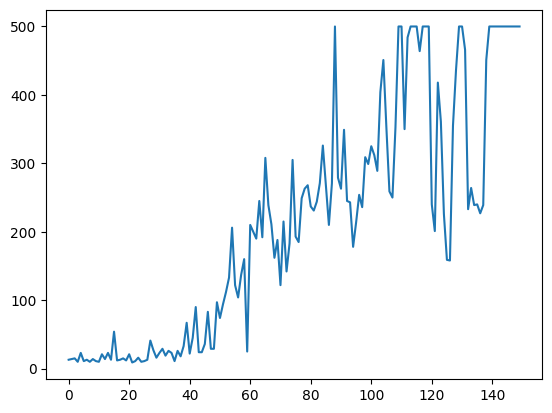

In [33]:
plot_rewards()